In [ ]:
pip install pandas matplotlib seaborn scikit-learn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Download the file
import urllib.request
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
urllib.request.urlretrieve(url, "Online_Retail.xlsx")
print("Download complete")

# Load the data
df = pd.read_excel("Online_Retail.xlsx")
print("Data shape:", df.shape)
df.head()

Download complete
Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)
print("After dropping missing CustomerID:", df.shape)

After dropping missing CustomerID: (406829, 8)


In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancelled orders:", df.shape)

After removing cancelled orders: (397924, 8)


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)  # should be datetime64[ns]

datetime64[ns]


In [ ]:
max_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date (snapshot date):", max_date)

Reference date (snapshot date): 2011-12-10 12:50:00


In [ ]:
# Group by CustomerID and calculate RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                               # Frequency (unique invoices)
    'TotalPrice': 'sum'                                   # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2053.793018
std,1721.889758,100.009747,7.705493,8988.248381
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,307.245000
50%,15299.000000,51.000000,2.000000,674.450000
75%,16778.500000,142.000000,5.000000,1661.640000
max,18287.000000,374.000000,210.000000,280206.020000


In [ ]:
def cap_outliers(series, lower_percentile=0.01, upper_percentile=0.99):
    lower = series.quantile(lower_percentile)
    upper = series.quantile(upper_percentile)
    return series.clip(lower, upper)

rfm['Recency'] = cap_outliers(rfm['Recency'])
rfm['Frequency'] = cap_outliers(rfm['Frequency'])
rfm['Monetary'] = cap_outliers(rfm['Monetary'])

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.337542,-0.618658,6.535901
1,-0.905744,0.615246,0.969427
2,-0.175003,-0.001706,0.071089
3,-0.735571,-0.618658,0.056899
4,2.177380,-0.618658,-0.451892


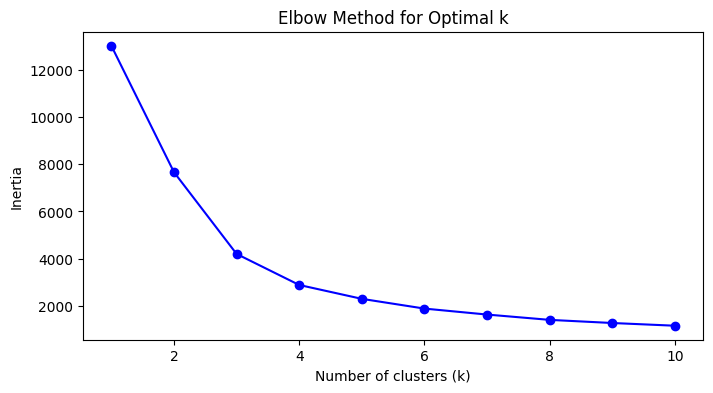

In [ ]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Add cluster labels to the original RFM table
rfm['Cluster'] = kmeans.labels_
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,19880.0918,3
1,12347.0,2,7,4310.0000,1
2,12348.0,75,4,1797.2400,0
3,12349.0,19,1,1757.5500,0
4,12350.0,310,1,334.4000,2


In [ ]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID':'Count'}).round(1)

cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,48.4,2.7,914.1,2621
1,22.3,10.6,4230.6,574
2,250.7,1.5,442.0,1035
3,18.3,23.7,15172.4,109


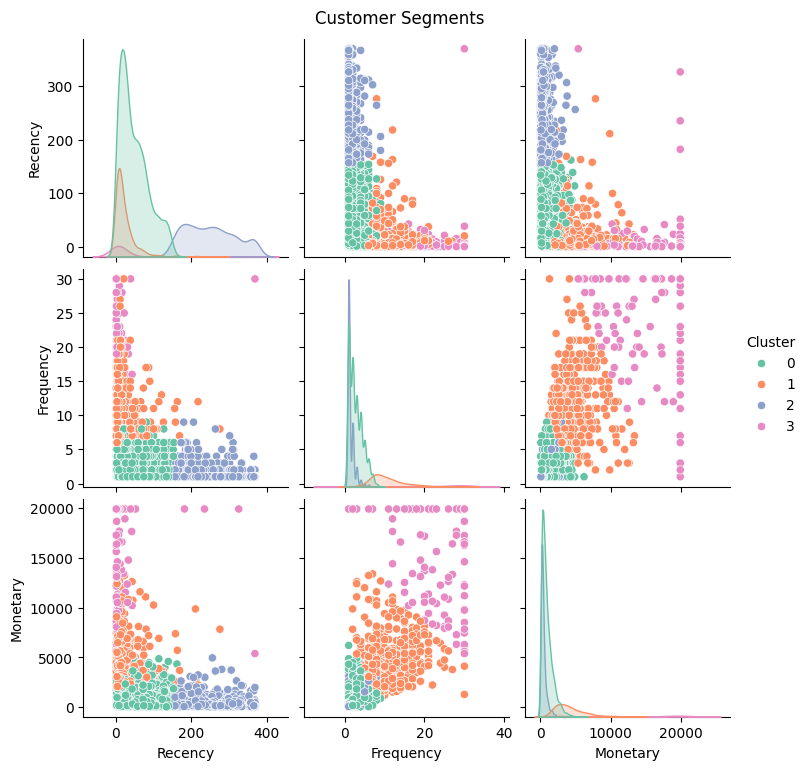

In [ ]:
sns.pairplot(rfm, vars=['Recency', 'Frequency', 'Monetary'], hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle('Customer Segments', y=1.02)
plt.show()

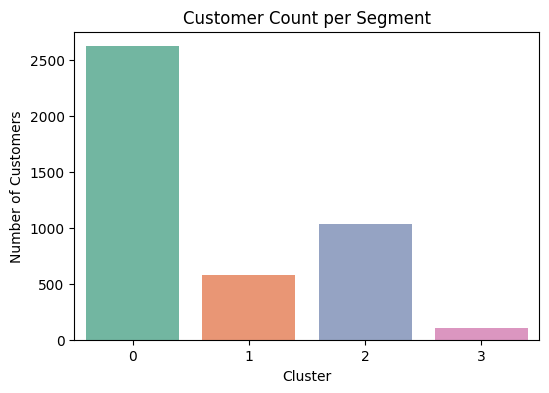

In [ ]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set2')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Count per Segment')
plt.show()

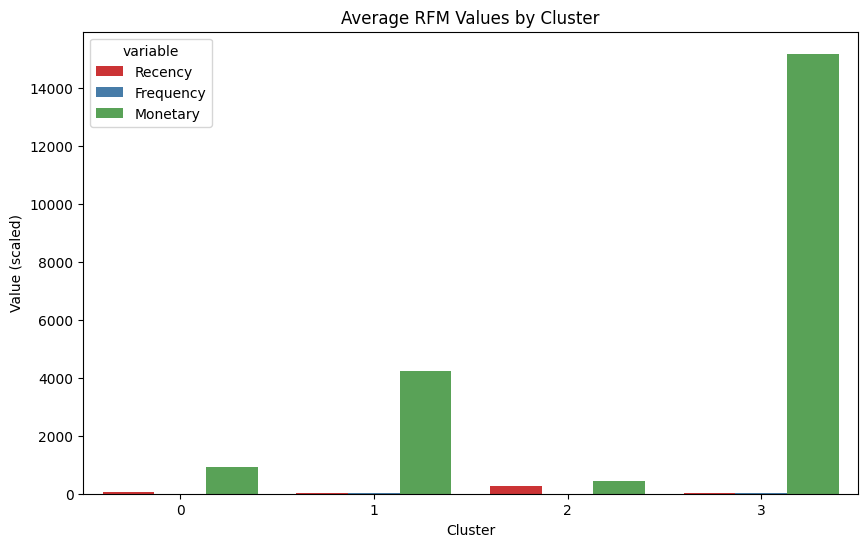

In [ ]:
# Melt the summary for plotting
summary_melted = cluster_summary.reset_index().melt(id_vars='Cluster', value_vars=['Recency', 'Frequency', 'Monetary'])
plt.figure(figsize=(10,6))
sns.barplot(data=summary_melted, x='Cluster', y='value', hue='variable', palette='Set1')
plt.title('Average RFM Values by Cluster')
plt.ylabel('Value (scaled)')
plt.show()

In [ ]:
rfm.to_csv('Customer_Segments.csv', index=False)
print("File saved: Customer_Segments.csv")

File saved: Customer_Segments.csv


In [ ]:
rfm.to_csv('rfm_segments.csv', index=False)